In [ ]:
import os 

import gdown
from zipfile import ZipFile
from io import BytesIO
from PIL import Image
 
from transformers import CLIPProcessor, CLIPModel

import torch
import ipyplot

In [ ]:
LOCAL_ZIP_NAME = 'travel_images.zip'
PATH_TO_ZIP = os.path.join('./images/', LOCAL_ZIP_NAME)
URL = 'https://drive.google.com/uc?id=1f2he9Ipx_SI_aAmrpEhfjKfrm7POuJti'

In [ ]:
def download_travel_images():
    """Download images from Google Drive."""
    if os.path.exists(PATH_TO_ZIP):
        print(f"Images already downloaded. Uisng {PATH_TO_ZIP}.")
    else: 
        if os.path.exists('./images/') is False:
            os.makedirs('./images/')
        print(f"Downloading images from {URL} to {PATH_TO_ZIP}.")
        gdown.download(URL, PATH_TO_ZIP, quiet=False)
        
    images = []
    with ZipFile(PATH_TO_ZIP, 'r') as zip_ref:
        for file_name in zip_ref.namelist():
            if file_name.lower().endswith(('png', 'jpg', 'jpeg')):
                with zip_ref.open(file_name) as file:
                    image = Image.open(BytesIO(file.read())).convert('RGB')
                    images.append(image)

    return images

In [ ]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
images = download_travel_images()

Images already downloaded. Uisng ./images/travel_images.zip.


# Compute similarities for travel images

In [ ]:
semantic_search_phrase = "Food"  

In [ ]:
with torch.no_grad():
    inputs = processor(text=[semantic_search_phrase], 
                    images=images, return_tensors="pt", padding=True)
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image # this is the image-text similarity score

In [ ]:
values, indices = logits_per_image.squeeze().topk(5) # Top-3

top_images, top_scores = [], []

for score, index in zip(values, indices):
    top_images.append(images[int(index.numpy())])
    score = score.numpy().tolist()
    top_scores.append(round(score, 2))

Scores: [26.32, 25.7, 25.1, 24.45, 24.02]



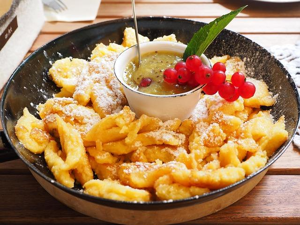
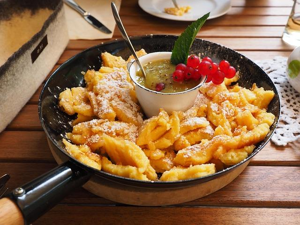
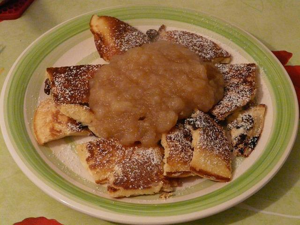
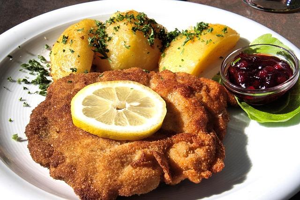
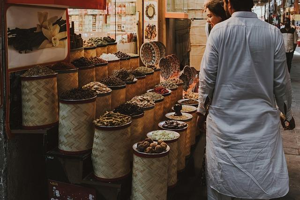


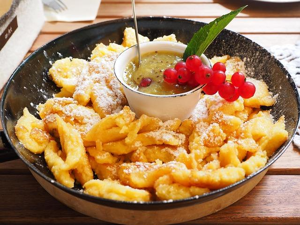
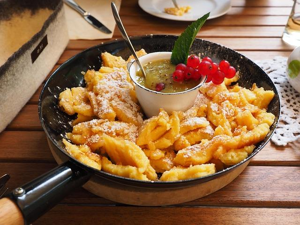
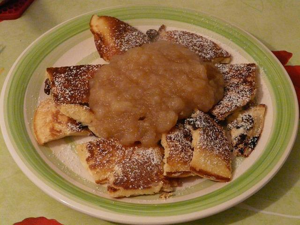
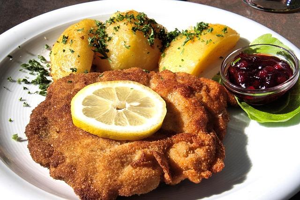
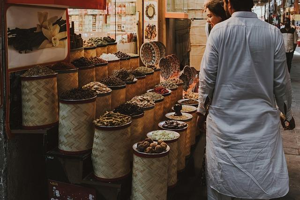

In [121]:
print (f"Scores: {top_scores}")
ipyplot.plot_images(top_images, img_width=300)

# Saving results

In [ ]:
SAVE_BASE_PATH = os.path.join('./images/semantic_search_results/travel/', semantic_search_phrase.replace(' ', '_'))
if not os.path.exists(SAVE_BASE_PATH):
    os.makedirs(SAVE_BASE_PATH)

for i, (image, score) in enumerate(zip(top_images, top_scores)):
    image.save(os.path.join(SAVE_BASE_PATH, f"{i+1}_score_{score}.jpg"))